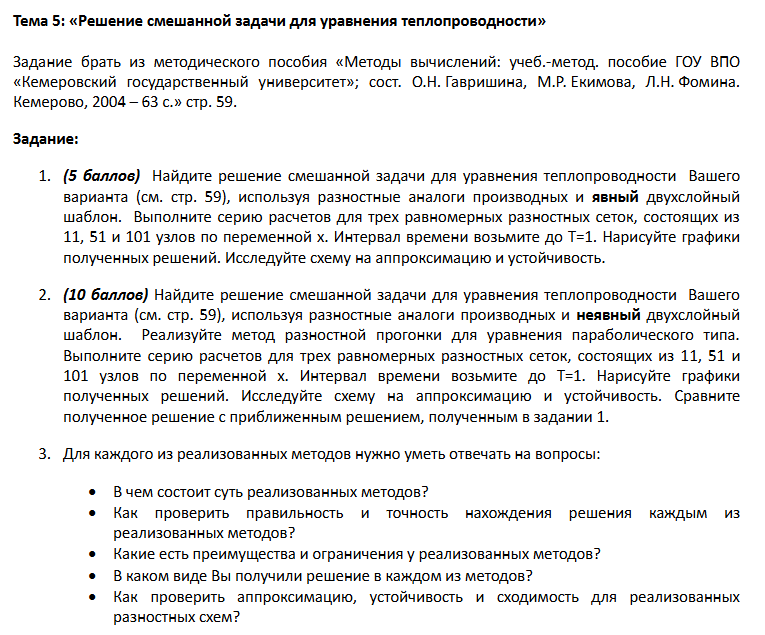

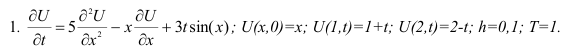

ЗАДАНИЕ 1: Явная схема
  Явная схема:  M= 10, h=0.1000, τ=0.001000, N=1000, σ=0.500
  Явная схема:  M= 50, h=0.0200, τ=0.000040, N=25000, σ=0.500
  Явная схема:  M=100, h=0.0100, τ=0.000010, N=100000, σ=0.500

ЗАДАНИЕ 2: Неявная схема
  Неявная схема: M= 10, h=0.1000, τ=0.001000, N=1000, σ=0.500
  Неявная схема: M= 50, h=0.0200, τ=0.000040, N=25000, σ=0.500
  Неявная схема: M=100, h=0.0100, τ=0.000010, N=100000, σ=0.500

ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ (M=10, неявная схема)
  t=0.0000: U(1,t)=1.000000 (ож=1.0000, δ=0.00e+00)  U(2,t)=2.000000 (ож=2.0000, δ=0.00e+00)
  t=0.2500: U(1,t)=1.250000 (ож=1.2500, δ=0.00e+00)  U(2,t)=1.750000 (ож=1.7500, δ=0.00e+00)
  t=0.5000: U(1,t)=1.500000 (ож=1.5000, δ=0.00e+00)  U(2,t)=1.500000 (ож=1.5000, δ=0.00e+00)
  t=1.0000: U(1,t)=2.000000 (ож=2.0000, δ=0.00e+00)  U(2,t)=1.000000 (ож=1.0000, δ=0.00e+00)

График сохранён: lab5_result.png


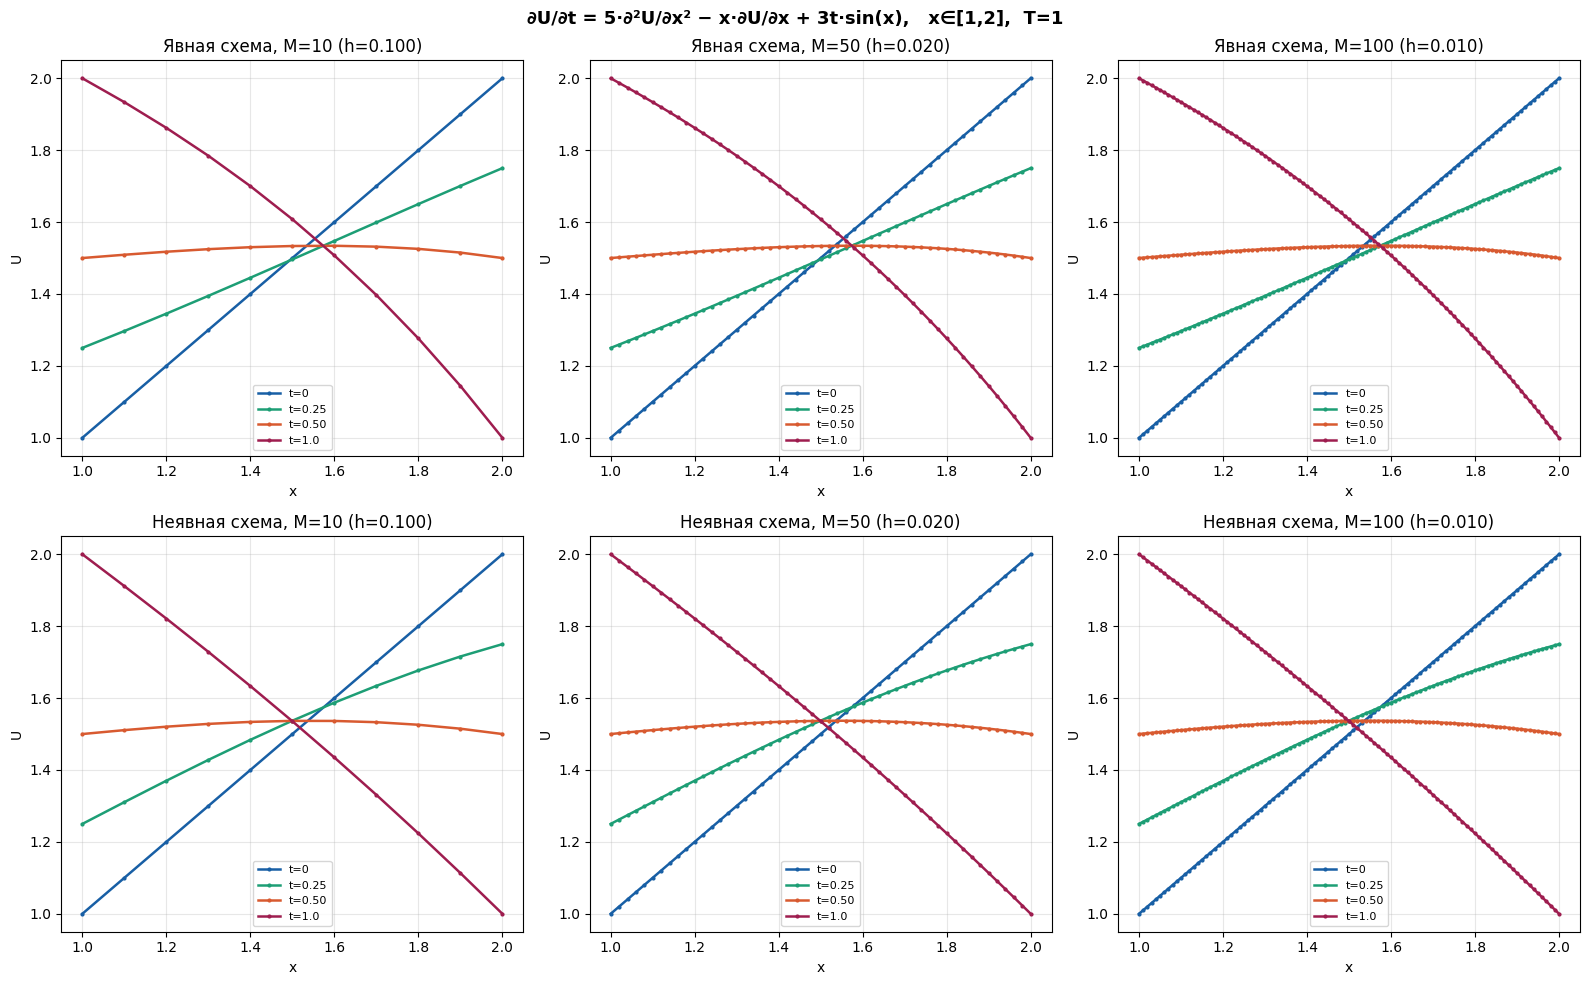

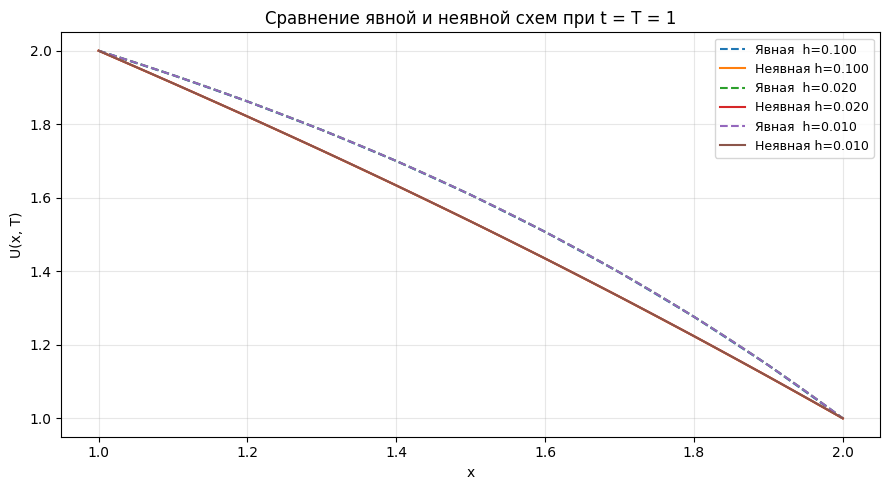

In [ ]:
"""
Лабораторная работа. Тема 5.
Решение смешанной задачи для уравнения теплопроводности.

Вариант 1:
    ∂U/∂t = 5·∂²U/∂x² − x·∂U/∂x + 3t·sin(x)

    U(x,0) = x           — начальное условие
    U(1,t) = 1 + t       — левое  ГУ I рода (Дирихле)
    U(2,t) = 2 − t       — правое ГУ I рода (Дирихле)

    x ∈ [1, 2],  t ∈ [0, T=1],  h = 0.1

Задание 1: явная схема  (условно устойчива: τ ≤ h²/(2a))
Задание 2: неявная схема (абсолютно устойчива, метод прогонки)
"""

import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════
#  ПАРАМЕТРЫ ЗАДАЧИ (общие для обоих методов)
# ═══════════════════════════════════════════════════════════

a    = 5.0          # коэффициент при ∂²U/∂x²
x_L  = 1.0          # левая граница по x
x_R  = 2.0          # правая граница по x
T    = 1.0          # конечный момент времени

def U_init(x):
    """Начальное условие U(x, 0) = x."""
    return x.copy()

def mu1(t):
    """Левое ГУ: U(1, t) = 1 + t."""
    return 1.0 + t

def mu2(t):
    """Правое ГУ: U(2, t) = 2 − t."""
    return 2.0 - t

def phi(x, t):
    """Правая часть: φ(x, t) = 3t·sin(x)."""
    return 3.0 * t * np.sin(x)

# ═══════════════════════════════════════════════════════════
#  МЕТОД ПРОГОНКИ (Томас) — для неявной схемы
# ═══════════════════════════════════════════════════════════

def thomas(A, B, C, F):
    """
    Трёхдиагональная система: A[i]·y[i-1] + B[i]·y[i] + C[i]·y[i+1] = F[i]

    Прямой ход: вычисляем прогоночные коэффициенты α и β
        y[i] = α[i]·y[i+1] + β[i]
    Обратный ход: восстанавливаем y[i] справа налево.
    """
    n     = len(B)
    alpha = np.zeros(n)
    beta  = np.zeros(n)

    # Прямой ход
    alpha[0] = -C[0] / B[0]
    beta[0]  =  F[0] / B[0]
    for i in range(1, n):
        denom    = B[i] + A[i] * alpha[i - 1]
        alpha[i] = -C[i] / denom
        beta[i]  = (F[i] - A[i] * beta[i - 1]) / denom

    # Обратный ход
    y = np.zeros(n)
    y[-1] = beta[-1]
    for i in range(n - 2, -1, -1):
        y[i] = alpha[i] * y[i + 1] + beta[i]
    return y

# ═══════════════════════════════════════════════════════════
#  ЗАДАНИЕ 1: ЯВНАЯ СХЕМА
#
#  Аппроксимация:
#    (U^{n+1}_m - U^n_m)/τ = a·(U^n_{m+1} - 2U^n_m + U^n_{m-1})/h²
#                           − x_m·(U^n_{m+1} - U^n_{m-1})/(2h)
#                           + φ(x_m, t_n)
#
#  Явная формула:
#    U^{n+1}_m = U^n_m + τ·[σ·(U^n_{m-1} - 2U^n_m + U^n_{m+1})
#                          − σ_q·(U^n_{m+1} - U^n_{m-1})
#                          + τ·φ(x_m, t_n)]
#
#    σ   = a·τ/h²    (коэф. диффузии)
#    σ_q = τ·x_m/(2h) (коэф. конвекции)
#
#  Условие устойчивости: σ ≤ 0.5  →  τ ≤ h²/(2a)
# ═══════════════════════════════════════════════════════════

def explicit_scheme(M):
    """
    Явная схема для M+1 узлов по x.
    M = число шагов по x, h = (x_R - x_L) / M.
    τ выбирается из условия устойчивости: τ = h²/(2a).
    """
    h   = (x_R - x_L) / M          # шаг по пространству
    tau = h**2 / (2 * a)            # шаг по времени (граница устойчивости)
    N   = round(T / tau)            # число шагов по времени
    sig = a * tau / h**2            # σ = a·τ/h² = 0.5 (на границе устойчивости)

    x = np.linspace(x_L, x_R, M + 1)

    print(f"  Явная схема:  M={M:>3}, h={h:.4f}, τ={tau:.6f}, N={N}, σ={sig:.3f}")

    U = U_init(x)                   # начальный слой

    save_at = {0, N // 4, N // 2, N}
    snaps   = {0: U.copy()}

    for n in range(N):
        tn  = n * tau
        U_new = U.copy()

        # Внутренние узлы m = 1, ..., M-1
        sq = tau * x[1:M] / (2 * h)                   # σ_q = τ·x_m/(2h)
        U_new[1:M] = (U[1:M]
                      + sig * (U[0:M-1] - 2*U[1:M] + U[2:M+1])
                      - sq  * (U[2:M+1] - U[0:M-1])
                      + tau * phi(x[1:M], tn))

        # Граничные условия
        U_new[0] = mu1((n + 1) * tau)
        U_new[M] = mu2((n + 1) * tau)

        U = U_new
        if (n + 1) in save_at:
            snaps[n + 1] = U.copy()

    return x, snaps, tau, N

# ═══════════════════════════════════════════════════════════
#  ЗАДАНИЕ 2: НЕЯВНАЯ СХЕМА
#
#  Аппроксимация (все производные на слое n+1):
#    (U^{n+1}_m - U^n_m)/τ = a·(U^{n+1}_{m-1} - 2U^{n+1}_m + U^{n+1}_{m+1})/h²
#                           − x_m·(U^{n+1}_{m+1} - U^{n+1}_{m-1})/(2h)
#                           + φ(x_m, t_n)
#
#  Система для внутренних узлов:
#    A_m·U^{n+1}_{m-1} + B_m·U^{n+1}_m + C_m·U^{n+1}_{m+1} = F_m
#
#    σ   = a·τ/h²
#    σ_q = τ·x_m/(2h)
#
#    A_m = -σ + σ_q       (нижняя диагональ)
#    B_m =  1 + 2σ        (главная диагональ)
#    C_m = -σ - σ_q       (верхняя диагональ)
#    F_m = U^n_m + τ·φ    (правая часть)
#
#  Абсолютно устойчива при любом τ.
# ═══════════════════════════════════════════════════════════

def implicit_scheme(M):
    """
    Неявная схема для M+1 узлов по x.
    Используем τ = h²/(2a) — для сравнения с явной схемой.
    """
    h   = (x_R - x_L) / M
    tau = h**2 / (2 * a)           # тот же шаг, что и в явной
    N   = round(T / tau)
    sig = a * tau / h**2           # σ = 0.5

    x = np.linspace(x_L, x_R, M + 1)

    print(f"  Неявная схема: M={M:>3}, h={h:.4f}, τ={tau:.6f}, N={N}, σ={sig:.3f}")

    U = U_init(x)

    save_at = {0, N // 4, N // 2, N}
    snaps   = {0: U.copy()}

    for n in range(N):
        tn     = n * tau
        t_next = (n + 1) * tau
        xm     = x[1:M]            # координаты внутренних узлов

        sq = tau * xm / (2 * h)                       # σ_q = τ·x_m/(2h)
        A  = -sig + sq                                 # нижняя диагональ
        B  = (1.0 + 2.0 * sig) * np.ones(M - 1)       # главная диагональ
        C  = -sig - sq                                 # верхняя диагональ
        F  = U[1:M] + tau * phi(xm, tn)               # правая часть

        # Учёт ГУ: переносим крайние члены в правую часть
        F[0]  -= A[0]  * mu1(t_next)
        F[-1] -= C[-1] * mu2(t_next)
        A[0]   = 0.0
        C[-1]  = 0.0

        U_int = thomas(A, B, C, F)

        U     = np.zeros(M + 1)
        U[0]  = mu1(t_next)
        U[M]  = mu2(t_next)
        U[1:M] = U_int

        if (n + 1) in save_at:
            snaps[n + 1] = U.copy()

    return x, snaps, tau, N

# ═══════════════════════════════════════════════════════════
#  РАСЧЁТЫ ДЛЯ ТРЁХ СЕТОК
# ═══════════════════════════════════════════════════════════

M_values = [10, 50, 100]   # M = число шагов (узлов = M+1: 11, 51, 101)

results_expl = {}
results_impl = {}

print("=" * 60)
print("ЗАДАНИЕ 1: Явная схема")
print("=" * 60)
for M in M_values:
    x_g, snaps, tau, N = explicit_scheme(M)
    results_expl[M] = (x_g, snaps, tau, N)

print()
print("=" * 60)
print("ЗАДАНИЕ 2: Неявная схема")
print("=" * 60)
for M in M_values:
    x_g, snaps, tau, N = implicit_scheme(M)
    results_impl[M] = (x_g, snaps, tau, N)

# ═══════════════════════════════════════════════════════════
#  ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ
# ═══════════════════════════════════════════════════════════

print()
print("=" * 60)
print("ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ (M=10, неявная схема)")
print("=" * 60)
x_g, snaps, tau, N = results_impl[10]
for key in sorted(snaps):
    tn  = key * tau
    U_s = snaps[key]
    el  = abs(U_s[0]  - mu1(tn))
    er  = abs(U_s[-1] - mu2(tn))
    print(f"  t={tn:.4f}: U(1,t)={U_s[0]:.6f} (ож={mu1(tn):.4f}, δ={el:.2e})  "
          f"U(2,t)={U_s[-1]:.6f} (ож={mu2(tn):.4f}, δ={er:.2e})")

# ═══════════════════════════════════════════════════════════
#  ГРАФИКИ
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('∂U/∂t = 5·∂²U/∂x² − x·∂U/∂x + 3t·sin(x),   x∈[1,2],  T=1',
             fontsize=13, fontweight='bold')

colors = ['#185FA5', '#1D9E75', '#D85A30', '#9E1D4F']

# Строка 1 — явная схема
for col, M in enumerate(M_values):
    ax = axes[0, col]
    x_g, snaps, tau, N = results_expl[M]
    lbl_map = {0: 't=0', N//4: f't={T/4:.2f}',
               N//2: f't={T/2:.2f}', N: f't={T:.1f}'}
    for i, (k, lbl) in enumerate(lbl_map.items()):
        ax.plot(x_g, snaps[k], color=colors[i], lw=1.8,
                marker='o', ms=2, label=lbl)
    ax.set_title(f'Явная схема, M={M} (h={( x_R-x_L)/M:.3f})')
    ax.set_xlabel('x'); ax.set_ylabel('U')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Строка 2 — неявная схема
for col, M in enumerate(M_values):
    ax = axes[1, col]
    x_g, snaps, tau, N = results_impl[M]
    lbl_map = {0: 't=0', N//4: f't={T/4:.2f}',
               N//2: f't={T/2:.2f}', N: f't={T:.1f}'}
    for i, (k, lbl) in enumerate(lbl_map.items()):
        ax.plot(x_g, snaps[k], color=colors[i], lw=1.8,
                marker='o', ms=2, label=lbl)
    ax.set_title(f'Неявная схема, M={M} (h={(x_R-x_L)/M:.3f})')
    ax.set_xlabel('x'); ax.set_ylabel('U')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
print("\nГрафик сохранён: lab5_result.png")
plt.show()

# ═══════════════════════════════════════════════════════════
#  СРАВНЕНИЕ ЯВНОЙ И НЕЯВНОЙ СХЕМ при t=T, M=10
# ═══════════════════════════════════════════════════════════

fig2, ax = plt.subplots(figsize=(9, 5))
for M in M_values:
    x_e, snaps_e, tau_e, N_e = results_expl[M]
    x_i, snaps_i, tau_i, N_i = results_impl[M]
    h_val = (x_R - x_L) / M
    ax.plot(x_e, snaps_e[N_e], '--', lw=1.5, label=f'Явная  h={h_val:.3f}')
    ax.plot(x_i, snaps_i[N_i], '-',  lw=1.5, label=f'Неявная h={h_val:.3f}')

ax.set_title('Сравнение явной и неявной схем при t = T = 1')
ax.set_xlabel('x'); ax.set_ylabel('U(x, T)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Уравнение описывает как меняется тмпература со временем под действием:<br/>
Диффузии<br/>
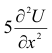<br/>
Конвекции<br/>
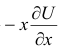<br/>
Источника тепла<br/> 


Делим область на сетку - узлы по x и по t

https://youtu.be/gITLugSS2L8?si=Tr_HOqA7VWugpY9z

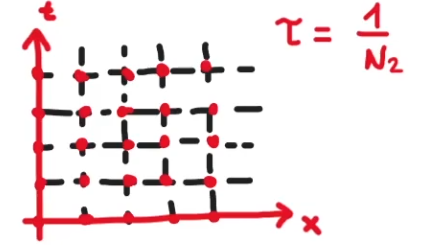

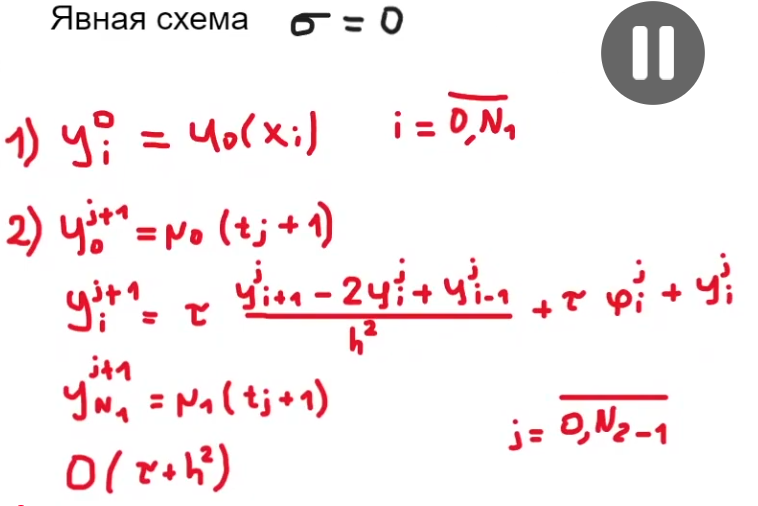

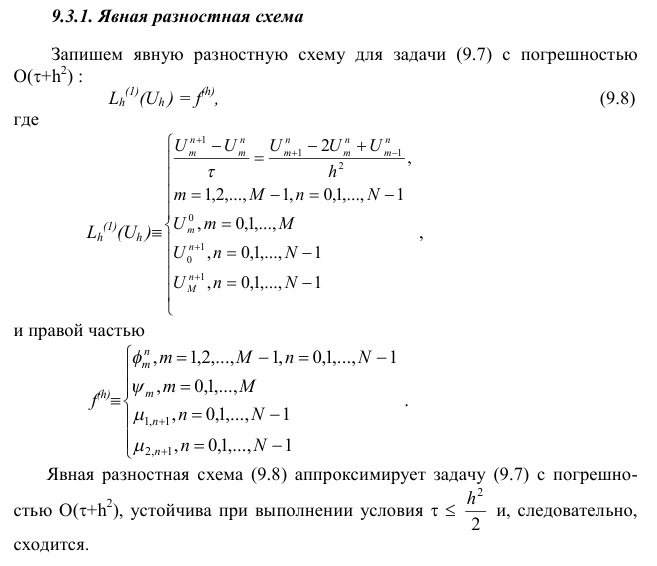

ЯВНАЯ СХЕМА — параметры сеток
  n= 11 узла: h=0.1000,  τ=0.001000,  N=  1000,  σ=0.50
  n= 51 узла: h=0.0200,  τ=0.000040,  N= 25000,  σ=0.50
  n=101 узла: h=0.0100,  τ=0.000010,  N=100000,  σ=0.50

ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ (n=11)
  t=0.0000:  U(1,t)=1.000000  (ож=1.0000, δ=0.00e+00)   U(2,t)=2.000000  (ож=2.0000, δ=0.00e+00)
  t=0.2500:  U(1,t)=1.250000  (ож=1.2500, δ=0.00e+00)   U(2,t)=1.750000  (ож=1.7500, δ=0.00e+00)
  t=0.5000:  U(1,t)=1.500000  (ож=1.5000, δ=0.00e+00)   U(2,t)=1.500000  (ож=1.5000, δ=0.00e+00)
  t=1.0000:  U(1,t)=2.000000  (ож=2.0000, δ=0.00e+00)   U(2,t)=1.000000  (ож=1.0000, δ=0.00e+00)


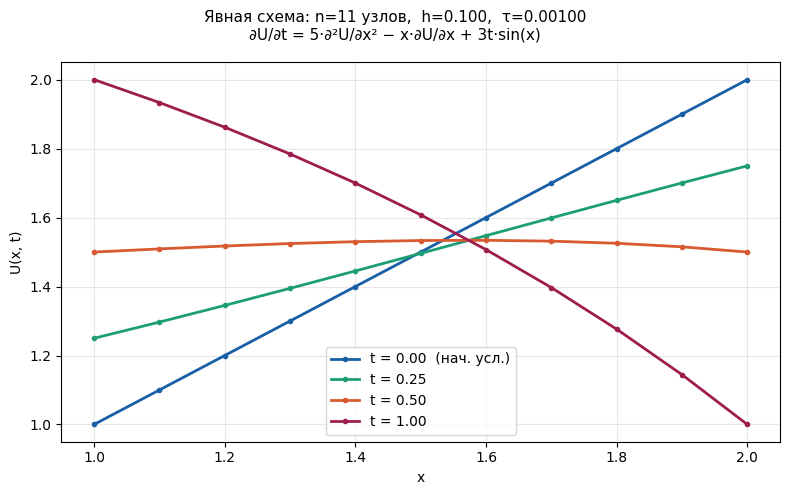

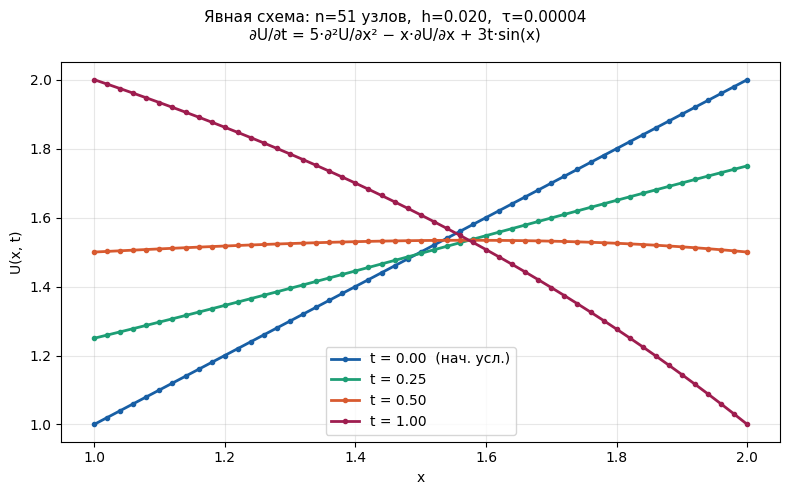

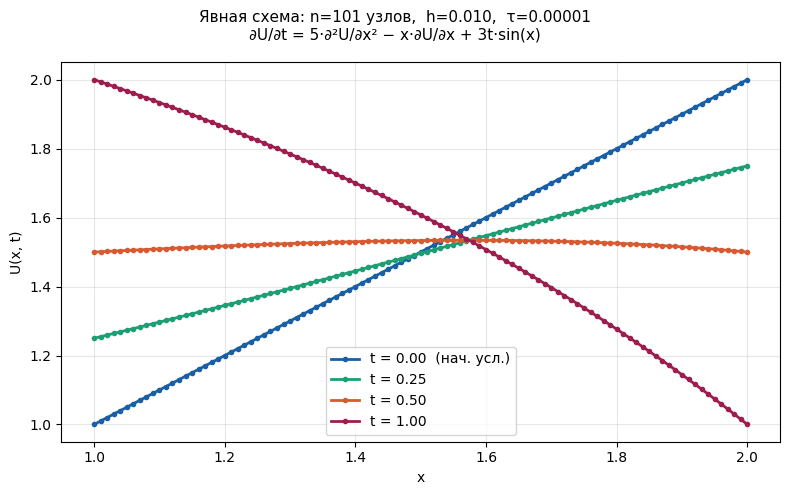

In [ ]:
"""
Уравнение: ∂U/∂t = 5·∂²U/∂x² − x·∂U/∂x + 3t·sin(x)
U(x,0)=x,  U(1,t)=1+t,  U(2,t)=2−t,  x∈[1,2],  T=1

Аппроксимация:
  (U^{n+1}_m - U^n_m)/τ = a·(U^n_{m+1} - 2U^n_m + U^n_{m-1})/h²
           − x_m·(U^n_{m+1} - U^n_{m-1})/(2h)
           + φ(x_m, t_n)

Явная схема — на каждом шаге по t новый слой вычисляется
явно через значения ПРЕДЫДУЩЕГО слоя:

  U^{n+1}_m = U^n_m
            + σ   · (U^n_{m-1} − 2U^n_m + U^n_{m+1})  ← диффузия
            − σ_q · (U^n_{m+1} − U^n_{m-1})            ← конвекция
            + τ   · φ(x_m, t_n)                         ← источник

Условие устойчивости: σ = a·τ/h² ≤ 0.5  →  τ ≤ h²/10
"""

import numpy as np
import matplotlib.pyplot as plt

# Параметры задачи

a   = 5.0   # коэффициент теплопроводности (насколько быстро тепло
            # распространяется по стержню — чем больше, тем быстрее)
x_L = 1.0   # левая граница: стержень начинается в x=1
x_R = 2.0   # правая граница: стержень заканчивается в x=2
T   = 1.0   # решаем от t=0 до t=1

# Начальное условие U(x, 0) = x:
# в начальный момент температура линейно растёт вдоль стержня
def U_init(x):
    return x.copy()

# Левое ГУ U(1, t) = 1 + t: температура на левом крае растёт (1→2)
def mu1(t):
    return 1.0 + t

# Правое ГУ U(2, t) = 2 − t: температура на правом крае падает (2→1)
def mu2(t):
    return 2.0 - t

# Источник тепла φ(x,t) = 3t·sin(x):
# дополнительный нагрев внутри стержня, зависящий от места и времени
def phi(x, t):
    return 3.0 * t * np.sin(x)


# Явная схема

def explicit_scheme(n_nodes):

    # Параметры сетки

    M = n_nodes - 1
    # M = число промежутков (11 узлов → 10 промежутков)

    h = (x_R - x_L) / M
    # h = шаг по x (пример: (2-1)/10 = 0.1)

    tau = h**2 / (2 * a)
    # τ = шаг по времени из условия устойчивости σ ≤ 0.5
    # σ = a·τ/h² ≤ 0.5  →  τ ≤ h²/(2a)
    # (пример при h=0.1: τ = 0.01/10 = 0.001)

    N = round(T / tau)
    # N = сколько шагов по времени до T=1
    # (пример: 1.0/0.001 = 1000 шагов)

    sig = a * tau / h**2
    # σ = a·τ/h² = 0.5 — число Куранта, мера скорости переноса тепла за шаг
    # должно быть ≤ 0.5, иначе схема расходится

    x = np.linspace(x_L, x_R, M + 1)
    # массив узлов: x[0]=1.0, x[1]=1.1, ..., x[M]=2.0

    print(f"  n={n_nodes:>3} узла: h={h:.4f},  τ={tau:.6f},  N={N:>6},  σ={sig:.2f}")

    # Начальные данные

    U = U_init(x)
    # U[m] = температура в узле m в текущий момент
    # В начале (t=0): U[m] = x[m]

    save_at = {0, N // 4, N // 2, N}
    # Шаги, на которых сохраняем снимок: t=0, T/4, T/2, T

    snaps = {0: U.copy()}
    # snaps[k] = слой температур на шаге k
    # .copy() — независимая копия, иначе все ключи указывали бы на один массив

    # Основной цикл по времени

    for n in range(N):
        # n = номер текущего слоя (0, 1, ..., N-1)
        # знаем U^n → вычисляем U^{n+1}

        tn = n * tau
        # текущее время t^n

        U_new = U.copy()
        # копия текущего слоя — туда пишем новые значения
        # важно: нельзя менять U на месте, т.к. при расчёте U_new[m]
        # нужны U[m-1] и U[m+1] из ТЕКУЩЕГО слоя

        xm = x[1:M]
        # координаты внутренних узлов (без границ)

        sq = tau * xm / (2 * h)
        # σ_q = τ·x_m/(2h) — коэффициент конвекции
        # получается из аппроксимации x·∂U/∂x центральной разностью

        # Явная формула пересчёта для внутренних узлов m=1,...,M-1:
        U_new[1:M] = (
            U[1:M]                                       # U^n_m — текущее значение

            + sig * (U[0:M-1] - 2*U[1:M] + U[2:M+1])   # σ·(U_{m-1} - 2U_m + U_{m+1})
                                                         # → аппроксимация a·∂²U/∂x² (диффузия)
                                                         # тепло перетекает от горячих соседей к холодным

            - sq  * (U[2:M+1] - U[0:M-1])               # σ_q·(U_{m+1} - U_{m-1})
                                                         # → аппроксимация x·∂U/∂x (конвекция)
                                                         # перенос тепла в одну сторону

            + tau * phi(xm, tn)                          # τ·φ(x_m, t_n)
                                                         # → вклад источника тепла
        )

        # Граничные условия на новом слое (задаются явно из условия задачи)
        U_new[0] = mu1((n + 1) * tau)   # левый край: U(1, t^{n+1}) = 1 + t
        U_new[M] = mu2((n + 1) * tau)   # правый край: U(2, t^{n+1}) = 2 - t

        U = U_new   # переходим на новый слой

        # ← ЗДЕСЬ сохраняем снимок если этот шаг в save_at
        if (n + 1) in save_at:
            snaps[n + 1] = U.copy()

    return x, snaps, tau, N


# Расчёт для трёх сеток

n_list  = [11, 51, 101]
# чем больше узлов → меньше h → точнее, но больше шагов по t

results = {}

print("=" * 60)
print("ЯВНАЯ СХЕМА — параметры сеток")
print("=" * 60)
for n in n_list:
    x_g, snaps, tau, N = explicit_scheme(n)
    results[n] = (x_g, snaps, tau, N)


# Проверка граничных условий

print()
print("=" * 60)
print("ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ (n=11)")
print("=" * 60)
x_g, snaps, tau, N = results[11]
for key in sorted(snaps):
    tn  = key * tau
    U_s = snaps[key]
    el  = abs(U_s[0]  - mu1(tn))   # отклонение на левом крае
    er  = abs(U_s[-1] - mu2(tn))   # отклонение на правом крае
    print(f"  t={tn:.4f}:  U(1,t)={U_s[0]:.6f}  (ож={mu1(tn):.4f}, δ={el:.2e})   "
          f"U(2,t)={U_s[-1]:.6f}  (ож={mu2(tn):.4f}, δ={er:.2e})")


# Графики

colors = ['#185FA5', '#1D9E75', '#D85A30', '#9E1D4F']

for n in n_list:
    x_g, snaps, tau, N = results[n]
    h_val = (x_R - x_L) / (n - 1)

    plt.figure(figsize=(8, 5))
    plt.suptitle(
        f'Явная схема: n={n} узлов,  h={h_val:.3f},  τ={tau:.5f}\n'
        '∂U/∂t = 5·∂²U/∂x² − x·∂U/∂x + 3t·sin(x)',
        fontsize=11
    )

    # номер шага → подпись времени на графике
    lbl_map = {
        0:     't = 0.00  (нач. усл.)',
        N//4:  f't = {T/4:.2f}',
        N//2:  f't = {T/2:.2f}',
        N:     f't = {T:.2f}',
    }

    # рисуем кривую U(x) для каждого сохранённого момента времени
    for i, (k, lbl) in enumerate(lbl_map.items()):
        plt.plot(x_g, snaps[k], color=colors[i], lw=2,
                 marker='o', ms=3, label=lbl)

    plt.xlabel('x')
    plt.ylabel('U(x, t)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


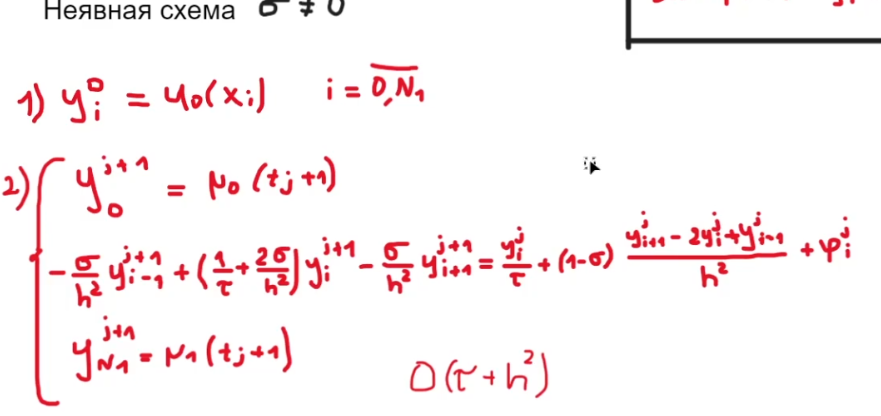

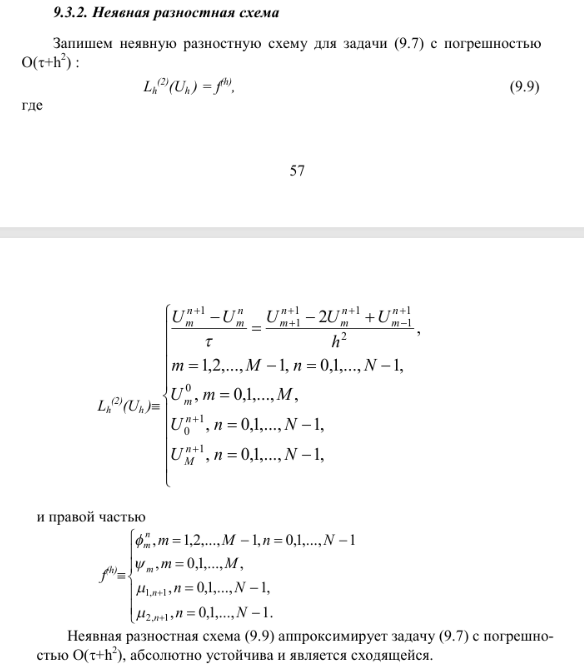

НЕЯВНАЯ СХЕМА
  n= 11: h=0.1000,  tau=0.001000,  N=  1000,  sigma=0.50
  n= 51: h=0.0200,  tau=0.000040,  N= 25000,  sigma=0.50
  n=101: h=0.0100,  tau=0.000010,  N=100000,  sigma=0.50

ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ (n=11)
  t=0.0000:  U(1,t)=1.000000  (ож=1.0000, delta=0.00e+00)   U(2,t)=2.000000  (ож=2.0000, delta=0.00e+00)
  t=0.2500:  U(1,t)=1.250000  (ож=1.2500, delta=0.00e+00)   U(2,t)=1.750000  (ож=1.7500, delta=0.00e+00)
  t=0.5000:  U(1,t)=1.500000  (ож=1.5000, delta=0.00e+00)   U(2,t)=1.500000  (ож=1.5000, delta=0.00e+00)
  t=1.0000:  U(1,t)=2.000000  (ож=2.0000, delta=0.00e+00)   U(2,t)=1.000000  (ож=1.0000, delta=0.00e+00)


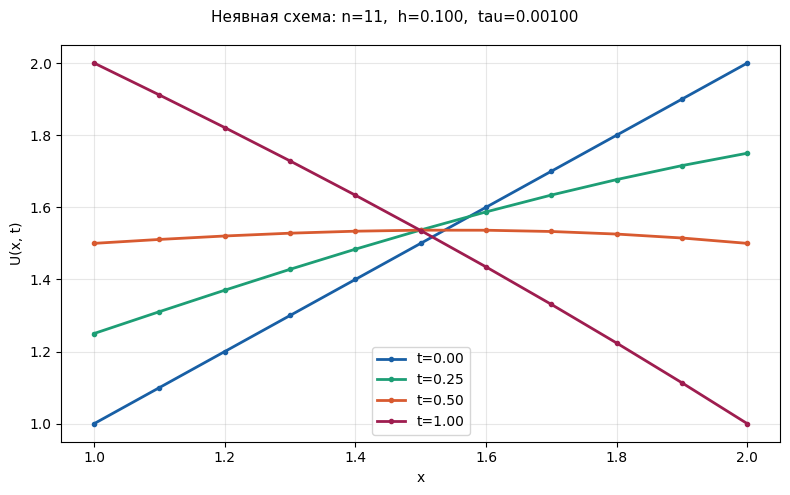

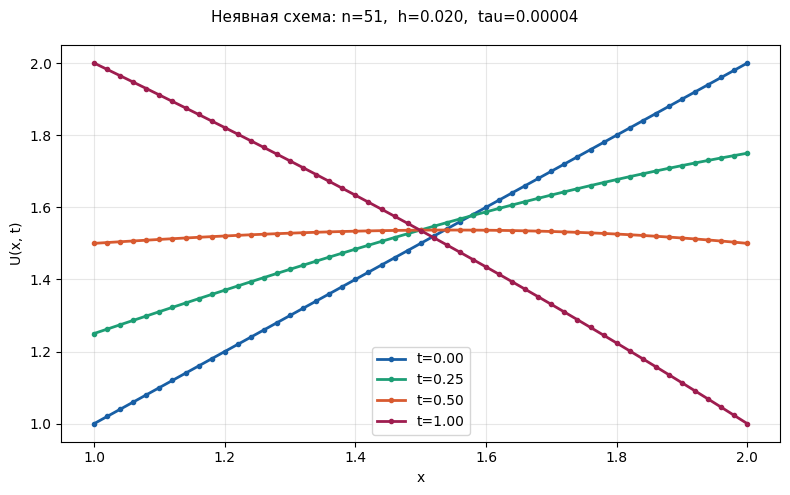

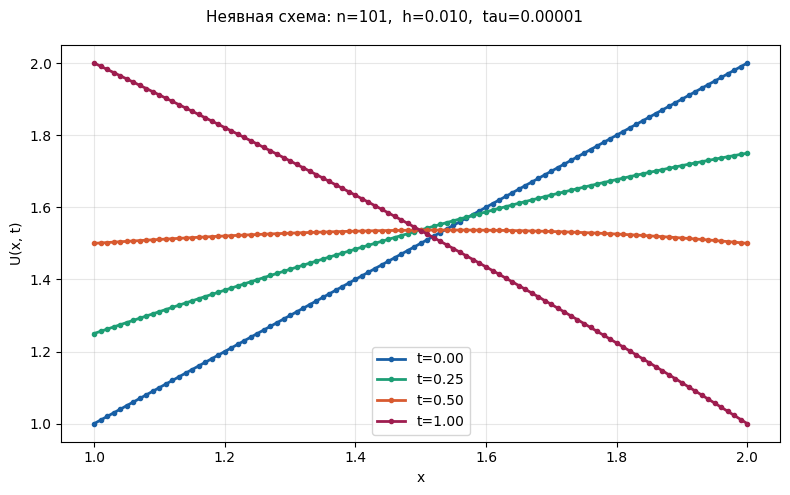


СРАВНЕНИЕ ЯВНОЙ И НЕЯВНОЙ при t=T
  n= 11: max|U_явн - U_неявн| = 7.2423e-02


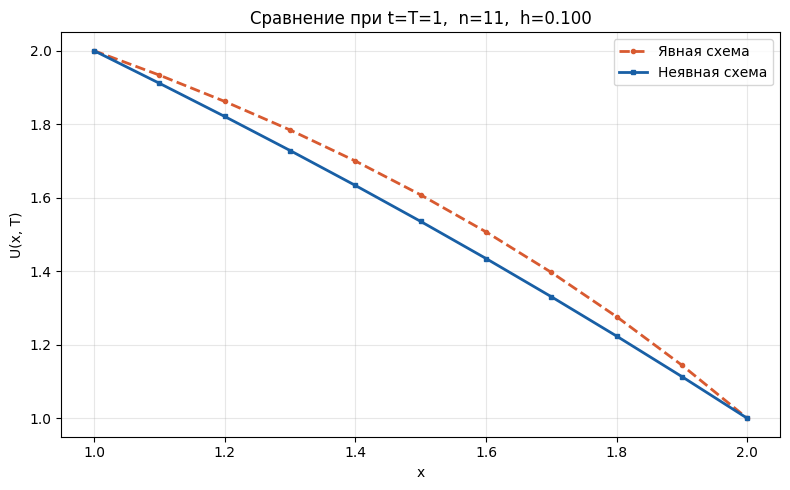

  n= 51: max|U_явн - U_неявн| = 7.3044e-02


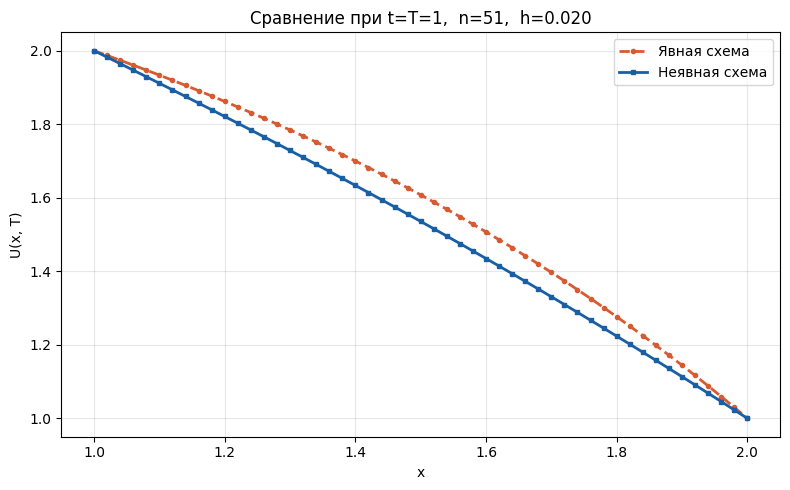

  n=101: max|U_явн - U_неявн| = 7.3053e-02


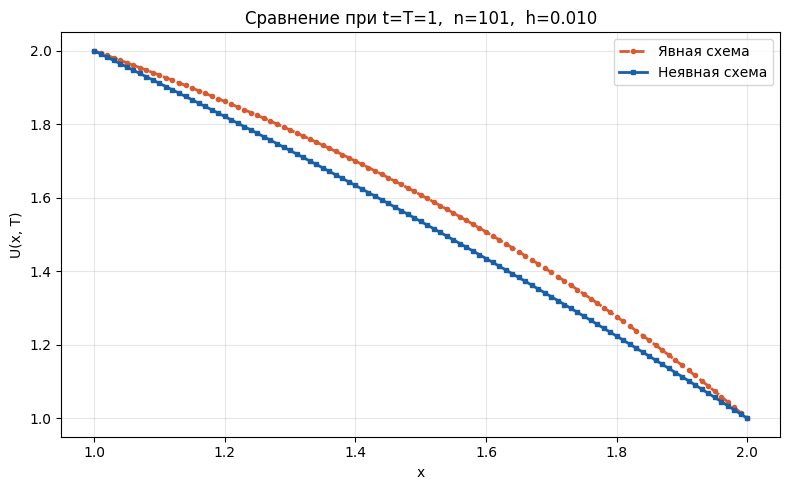

In [ ]:
'''
Аппроксимация (все производные на слое n+1):
(U^{n+1}_m - U^n_m)/τ = a·(U^{n+1}_{m-1} - 2U^{n+1}_m + U^{n+1}_{m+1})/h²
                       − x_m·(U^{n+1}_{m+1} - U^{n+1}_{m-1})/(2h)
                       + φ(x_m, t_n)

Система для внутренних узлов:
  A_m·U^{n+1}_{m-1} + B_m·U^{n+1}_m + C_m·U^{n+1}_{m+1} = F_m

  σ   = a·τ/h²
  σ_q = τ·x_m/(2h)

  A_m = -σ + σ_q       (нижняя диагональ)
  B_m =  1 + 2σ        (главная диагональ)
  C_m = -σ - σ_q       (верхняя диагональ)
  F_m = U^n_m + τ·φ    (правая часть)

  Абсолютно устойчива при любом τ.
'''

import numpy as np
import matplotlib.pyplot as plt

# Параметры задачи
a   = 5.0    # коэффициент теплопроводности
x_L = 1.0    # левая граница
x_R = 2.0    # правая граница
T   = 1.0    # решаем от t=0 до t=1

# Начальное условие: температура равна координате
def U_init(x):  return x.copy()
# Левое ГУ: U(1,t) = 1+t
def mu1(t):     return 1.0 + t
# Правое ГУ: U(2,t) = 2-t
def mu2(t):     return 2.0 - t
# Источник тепла
def phi(x, t):  return 3.0*t*np.sin(x)


# Метод прогонки (Томас)
def thomas(A, B, C, F):
    # Решает: A[i]*y[i-1] + B[i]*y[i] + C[i]*y[i+1] = F[i]
    # Ключевая идея: y[i] = alpha[i]*y[i+1] + beta[i]
    n     = len(B)
    alpha = np.zeros(n)   # прогоночные коэффициенты xi
    beta  = np.zeros(n)   # прогоночные коэффициенты eta
    # Прямой ход: начало (i=0)
    alpha[0] = -C[0] / B[0]
    beta[0]  =  F[0] / B[0]
    # Прямой ход: i=1,...,n-1 (слева направо)
    for i in range(1, n):
        denom    = B[i] + A[i] * alpha[i - 1]   # знаменатель
        alpha[i] = -C[i] / denom
        beta[i]  = (F[i] - A[i] * beta[i - 1]) / denom
    # Обратный ход: y[i] = alpha[i]*y[i+1] + beta[i] (справа налево)
    y = np.zeros(n)
    y[-1] = beta[-1]   # последний узел из beta
    for i in range(n - 2, -1, -1):
        y[i] = alpha[i] * y[i + 1] + beta[i]
    return y


# Неявная схема
def implicit_scheme(n_nodes):

    # Параметры сетки
    M   = n_nodes - 1             # число промежутков
    h   = (x_R - x_L) / M         # шаг по x
    tau = h**2 / (2 * a)          # шаг по t — такой же как у явной для сравнения
                                  # для неявной tau может быть ЛЮБЫМ
    N   = round(T / tau)          # число шагов по t
    sig = a * tau / h**2          # sigma=0.5 (устойчивость не зависит от sigma)
    x   = np.linspace(x_L, x_R, M + 1)   # узлы сетки

    print(f"  n={n_nodes:>3}: h={h:.4f},  tau={tau:.6f},  N={N:>6},  sigma={sig:.2f}")

    # Начальные данные
    U       = U_init(x)           # начальный слой: U[m]=x[m] при t=0
    save_at = {0, N // 4, N // 2, N}  # шаги для сохранения снимков
    snaps   = {0: U.copy()}       # snaps[k] = слой на шаге k

    # Цикл по времени
    for n in range(N):
        tn     = n * tau           # текущее время t^n
        t_next = (n + 1) * tau    # следующее время t^{n+1}
        xm     = x[1:M]           # внутренние узлы

        # Диагонали матрицы
        sq = tau * xm / (2 * h)   # sigma_q = tau*x_m/(2h)

        A  = -sig + sq
        # нижняя диагональ: коэф. при U^{n+1}_{m-1} (левый сосед на НОВОМ слое)

        B  = (1.0 + 2.0 * sig) * np.ones(M - 1)
        # главная диагональ: 1 от (U^{n+1}-U^n)/tau, 2*sigma от диффузии

        C  = -sig - sq
        # верхняя диагональ: коэф. при U^{n+1}_{m+1} (правый сосед на НОВОМ слое)

        F  = U[1:M] + tau * phi(xm, tn)
        # правая часть: U^n_m (текущий, известен) + tau*phi (источник)

        # Шаг 3б: учёт ГУ — переносим границы в правую часть F
        F[0]  -= A[0]  * mu1(t_next)   # для m=1: F[0] -= A[0]*mu1
        F[-1] -= C[-1] * mu2(t_next)   # для m=M-1: F[-1] -= C[-1]*mu2
        A[0]   = 0.0   # обнуляем — ГУ уже в F
        C[-1]  = 0.0   # обнуляем — ГУ уже в F

        # Шаг 3в: решаем систему методом прогонки
        U_int  = thomas(A, B, C, F)
        # U_int — значения внутренних узлов на новом слое

        # Шаг 3г: собираем полный новый слой
        U      = np.zeros(M + 1)
        U[0]   = mu1(t_next)   # левый край из ГУ
        U[M]   = mu2(t_next)   # правый край из ГУ
        U[1:M] = U_int         # внутренние из прогонки

        if (n + 1) in save_at:
            snaps[n + 1] = U.copy()   # снимок для графика

    return x, snaps, tau, N


# Расчёт для трёх сеток
n_list   = [11, 51, 101]
results2 = {}   # отдельный словарь — не перезаписываем results из задания 1

print("=" * 60)
print("НЕЯВНАЯ СХЕМА")
print("=" * 60)
for n in n_list:
    x_g, snaps, tau, N = implicit_scheme(n)
    results2[n] = (x_g, snaps, tau, N)


# Проверка граничных условий (delta должна быть ~0)
print()
print("=" * 60)
print("ПРОВЕРКА ГРАНИЧНЫХ УСЛОВИЙ (n=11)")
print("=" * 60)
x_g, snaps, tau, N = results2[11]
for key in sorted(snaps):
    tn  = key * tau
    U_s = snaps[key]
    el  = abs(U_s[0]  - mu1(tn))   # отклонение на левом крае
    er  = abs(U_s[-1] - mu2(tn))   # отклонение на правом крае
    print(f"  t={tn:.4f}:  U(1,t)={U_s[0]:.6f}  (ож={mu1(tn):.4f}, delta={el:.2e})   "
          f"U(2,t)={U_s[-1]:.6f}  (ож={mu2(tn):.4f}, delta={er:.2e})")


# Графики: отдельный для каждой сетки
colors = ["#185FA5", "#1D9E75", "#D85A30", "#9E1D4F"]

for n in n_list:
    x_g, snaps, tau, N = results2[n]
    h_val = (x_R - x_L) / (n - 1)
    plt.figure(figsize=(8, 5))
    plt.suptitle(f"Неявная схема: n={n},  h={h_val:.3f},  tau={tau:.5f}", fontsize=11)
    lbl_map = {0: "t=0.00", N//4: f"t={T/4:.2f}", N//2: f"t={T/2:.2f}", N: f"t={T:.2f}"}
    # рисуем кривую U(x) для каждого сохранённого момента
    for i, (k, lbl) in enumerate(lbl_map.items()):
        plt.plot(x_g, snaps[k], color=colors[i], lw=2, marker="o", ms=3, label=lbl)
    plt.xlabel("x"); plt.ylabel("U(x, t)")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Сравнение явной и неявной при t=T
# Запускать ПОСЛЕ ячейки задания 1 (нужна переменная results)
print()
print("=" * 60)
print("СРАВНЕНИЕ ЯВНОЙ И НЕЯВНОЙ при t=T")
print("=" * 60)
try:
    for n in n_list:
        x_e, snaps_e, tau_e, N_e = results[n]    # явная (из задания 1)
        x_i, snaps_i, tau_i, N_i = results2[n]   # неявная
        h_val = (x_R - x_L) / (n - 1)
        U_impl = np.interp(x_e, x_i, snaps_i[N_i])   # приводим к узлам явной
        diff   = np.max(np.abs(snaps_e[N_e] - U_impl))  # макс. разница
        print(f"  n={n:>3}: max|U_явн - U_неявн| = {diff:.4e}")
        plt.figure(figsize=(8, 5))
        plt.title(f"Сравнение при t=T=1,  n={n},  h={h_val:.3f}")
        plt.plot(x_e, snaps_e[N_e], "--", lw=2, color="#D85A30",
                 marker="o", ms=3, label="Явная схема")
        plt.plot(x_i, snaps_i[N_i], "-",  lw=2, color="#185FA5",
                 marker="s", ms=3, label="Неявная схема")
        plt.xlabel("x"); plt.ylabel("U(x, T)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
except NameError:
    print("  Сначала запусти ячейку задания 1 (переменная results не найдена)")


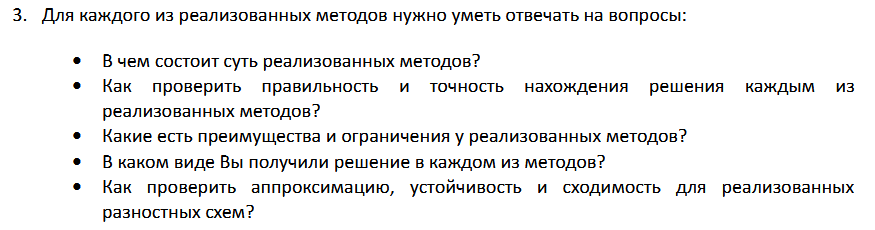


---

**В чём состоит суть реализованных методов?**

Оба метода решают уравнение `∂U/∂t = 5·∂²U/∂x² − x·∂U/∂x + 3t·sin(x)` методом конечных разностей: область `[1,2]×[0,1]` разбивается на сетку с шагами `h` по `x` и `τ` по `t`, производные заменяются разностными формулами.

- **Явная схема** — новый слой `U^{n+1}` вычисляется напрямую через известный слой `U^n` по явной формуле (одно выражение на каждый внутренний узел). Никаких систем решать не нужно.
- **Неявная схема** — производные аппроксимируются на новом слое `U^{n+1}`, что порождает трёхдиагональную систему линейных уравнений на каждом шаге по времени. Система решается методом прогонки (алгоритм Томаса): прямой ход вычисляет прогоночные коэффициенты, обратный — восстанавливает решение.

---

**Как проверить правильность и точность нахождения решения?**

1. **Граничные условия** — на каждом сохранённом слое сравниваем крайние значения с точными ГУ:
```
δ_L = |U[0]  − mu1(t)|   # должно быть ≈ 0
δ_R = |U[-1] − mu2(t)|   # должно быть ≈ 0
```
2. **Сравнение двух схем** — при одинаковом `h` явная и неявная схемы должны давать близкие результаты. Вычисляем `max|U_явн − U_неявн|` и убеждаемся, что оно мало.
3. **Сходимость по сетке** — запускаем на трёх сетках (`M = 10, 50, 100`) и проверяем, что при уменьшении `h` решения сходятся.

---

**Какие есть преимущества и ограничения у реализованных методов?**

| | Явная схема | Неявная схема |
|---|---|---|
| **Реализация** | Очень простая — одна формула | Сложнее — требует метода прогонки |
| **Устойчивость** | Условная: `σ = aτ/h² ≤ 0.5`, т.е. `τ ≤ h²/(2a)` | Безусловная — устойчива при любом `τ` |
| **Шаг по времени** | Жёстко ограничен: при `a=5, h=0.1` → `τ = 0.001` | Можно брать большим, не теряя устойчивости |
| **Стоимость** | При `h → h/2` шагов по `t` в 4 раза больше | Шагов меньше, но каждый требует решения системы |
| **Точность** | `O(τ) + O(h²)` | `O(τ) + O(h²)` |

---

**В каком виде получено решение в каждом из методов?**

Решение получено в виде **числовой сетки** — набора векторов `U[m]` в узлах `x_m` для фиксированных моментов времени `t = 0, T/4, T/2, T` (словарь `snaps`). Из этих векторов строятся графики `U(x, t)`. Аналитическое выражение не вычисляется — только приближённые числовые значения в узлах сетки.

---

**Как проверить аппроксимацию, устойчивость и сходимость для реализованных разностных схем?**

- **Аппроксимация** — подставить в разностную схему точное решение и разложить в ряд Тейлора. Для обеих схем: временная производная аппроксимирована с точностью `O(τ)`, пространственные (диффузия и конвекция через центральные разности) — с точностью `O(h²)`. Итоговый порядок: `O(τ + h²)`.
- **Устойчивость** — для явной схемы проверяем условие Куранта: `σ = aτ/h² ≤ 0.5`. При нарушении схема расходится (числа уходят в `±∞`). Неявная схема абсолютно устойчива по анализу Фон Неймана при любом `τ > 0`.
- **Сходимость** — по теореме Лакса: *аппроксимация + устойчивость → сходимость*. Практически: запускаем на сетках `M = 10, 50, 100` и убеждаемся, что максимальное расхождение между соседними сетками убывает примерно в 4 раза при удвоении `M` (второй порядок по `h`).